<a href="https://colab.research.google.com/github/LaxmiBandi/Machine_Learning/blob/main/Lab6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Load dataset
data = pd.read_csv("/content/iris (1).csv")

X = data.drop("species",axis=1)
y = data["species"]

# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model
knn = KNeighborsClassifier(n_neighbors=3)

# Train
knn.fit(X_train,y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))

# Confusion Matrix
print(confusion_matrix(y_test,y_pred))

# Classification Report
print(classification_report(y_test,y_pred))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

data = pd.read_csv("/content/diabetes.csv")

X = data.drop("Outcome",axis=1)
y = data["Outcome"]

# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.6948051948051948
Confusion Matrix
[[79 20]
 [27 28]]


Best K: 11
Accuracy: 0.7540983606557377


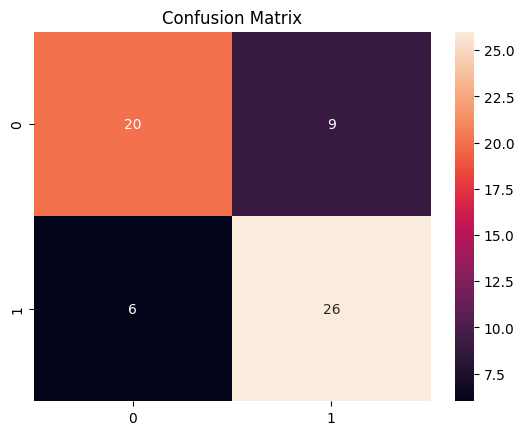

              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

data = pd.read_csv("/content/heart.csv")

X = data.drop("target",axis=1)
y = data["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scores=[]

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,y_pred))

# Best K
best_k = scores.index(max(scores))+1
print("Best K:",best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

# Confusion Matrix Plot
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test,y_pred))